# Notebook 4: Model Training
### Nutrition Intelligence System | Predicting Protein, Fat, and Sugar in Foods



---


In this notebook we perform data scaling, train test splitting, model training, evaluation and comparison. The training will be done on both the original clean data and the corrupted cleaned data. We will then compare the performance of each model on both datasets to measure the impact of data quality on model performance.


## Table of Contents

1. [Training on original data](#1-training-on-original-data)
2. [Corrupted cleaned data](#2-corrupted-cleaned-data)
  




 ### 1.Training on original data

 the first is we split our data into training and test data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
# File paths in  drive
file_path1 = '/content/drive/MyDrive/nutri_project/data/final_corrupted_food_dataset.csv'
file_path2 = '/content/drive/MyDrive/nutri_project/data/final_original_food_dataset.csv'

# Load svs for each file
original_food_dataset = pd.read_csv(file_path2)
corrupted_food_dataset = pd.read_csv(file_path1)

Mounted at /content/drive


In [ ]:
from sklearn.model_selection import train_test_split
#specify the target variables
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
#x takes the all columns except the targets hese are our feature
X = original_food_dataset.drop(columns=targets)
#y takes our target variables
y = original_food_dataset[targets]
#we split data into train and test data with test size 0.2 which means 20% of data is for test
#we put random state as 42 which help us generate same data combination everytime
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)

X_train: (6234, 70)


 ### 1.1 Random Forest
#### 1.1.1 Model Training


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model
def evaluate(y_test, y_pred,model_name):

    print(model_name)
    print("=" * 30)

    # Loop through each target
    for i, target in enumerate(targets):

        mae  = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
        r2   = r2_score(y_test.iloc[:, i], y_pred[:, i])

        print(f"\n{target}")
        print(f"R²  : {r2:.3f}")
        print(f"MAE : {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")


# Create Random Forest model
rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        #prallel processing
        n_jobs=-1
    )
)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)



#### 1.1.2 Model Evaluation

In [ ]:
# Evaluate Random Forest
evaluate(y_test, y_pred_rf,"Random Forest")

Random Forest

Protein
R²  : 0.908
MAE : 1.343
RMSE: 3.391

Total lipid (fat)
R²  : 0.960
MAE : 1.610
RMSE: 3.368

Sugars, Total
R²  : 0.754
MAE : 2.750
RMSE: 6.842


#### 1.1.3 Overfitting Checking

In [ ]:
# Predict on training data
y_pred_train = rf.predict(X_train)

print("Training Performance")
print("="*30)
evaluate(y_train, y_pred_train,"Random Forest")

print("\nTesting Performance")
print("="*30)
evaluate(y_test, y_pred_rf,"Random Forest")

Training Performance
Random Forest

Protein
R²  : 0.989
MAE : 0.479
RMSE: 1.138

Total lipid (fat)
R²  : 0.994
MAE : 0.618
RMSE: 1.266

Sugars, Total
R²  : 0.968
MAE : 0.925
RMSE: 2.367

Testing Performance
Random Forest

Protein
R²  : 0.908
MAE : 1.343
RMSE: 3.391

Total lipid (fat)
R²  : 0.960
MAE : 1.610
RMSE: 3.368

Sugars, Total
R²  : 0.754
MAE : 2.750
RMSE: 6.842


In [ ]:

data = {
    "Target": ["Protein", "Total Lipid (Fat)", "Sugars, Total"],
    "Train R²": [0.989, 0.994, 0.968],
    "Test R²": [0.908, 0.960, 0.754]
}

df = pd.DataFrame(data)

# Calculate Overfitting Gap
df["Gap"] = df["Train R²"] - df["Test R²"]

# Overfitting level
def overfit_level(gap):
    if gap < 0.02:
        return "Low"
    elif gap < 0.10:
        return "Moderate"
    else:
        return "High"

df["Overfitting Level"] = df["Gap"].apply(overfit_level)

# Round values
df = df.round(3)

print(df)

              Target  Train R²  Test R²    Gap Overfitting Level
0            Protein     0.989    0.908  0.081          Moderate
1  Total Lipid (Fat)     0.994    0.960  0.034          Moderate
2      Sugars, Total     0.968    0.754  0.214              High


**Interpretation:** Random Forest achieves Test R²=0.909 for Protein and 0.959 for Fat with MAE of 1.338g and 1.624g respectively, indicating predictions are off by roughly 1 to 2 g on average. The Sugar overfitting gap of 0.212 is large, caused by trees memorizing training patterns which is not always true  for sugar(for example we can find food that both have vegetable as a category but it doesn't necessarly mean that the amount of sugar will be close)

 ### 1.2 Gradient Boosting
#### 1.2.1 Model Training

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = MultiOutputRegressor(GradientBoostingRegressor(
    #number of boosting stage
    n_estimators=100,
    #how much each tree contributes
    learning_rate=0.1,
    max_depth=4,
    random_state=42
))

gb.fit(X_train, y_train)
y_pred_gb_train = gb.predict(X_train)
y_pred_gb_test= gb.predict(X_test)


#### 1.2.2 Model Evaluation

In [ ]:

print("Training Performance")
print("="*30)
evaluate(y_train, y_pred_gb_train, "Gradient Boosting - Train")

print("\nTesting Performance")
print("="*30)
evaluate(y_test, y_pred_gb_test,  "Gradient Boosting - Test")

Training Performance
Gradient Boosting - Train

Protein
R²  : 0.967
MAE : 1.325
RMSE: 1.955

Total lipid (fat)
R²  : 0.976
MAE : 1.674
RMSE: 2.533

Sugars, Total
R²  : 0.897
MAE : 2.216
RMSE: 4.259

Testing Performance
Gradient Boosting - Test

Protein
R²  : 0.910
MAE : 1.712
RMSE: 3.358

Total lipid (fat)
R²  : 0.961
MAE : 1.973
RMSE: 3.327

Sugars, Total
R²  : 0.766
MAE : 3.122
RMSE: 6.667


**Interpretation:** Gradient Boosting achieves good results with Test R²=0.910, 0.961 and 0.766 for Protein, Fat and Sugar. Its train-test gaps are the small to moderate, meaning it learnedto generalize patterns rather than memorizing training data.

In [ ]:

data = {
    "Target": ["Protein", "Total Lipid (Fat)", "Sugars, Total"],
    "Train R²": [0.967, 0.976, 0.897],
    "Test R²": [0.910, 0.961, 0.766]
}

df = pd.DataFrame(data)

# Calculate Overfitting Gap
df["Gap"] = df["Train R²"] - df["Test R²"]
def overfit_level(gap):
    if gap < 0.02:
        return "Low"
    elif gap < 0.10:
        return "Moderate"
    else:
        return "High"

df["Overfitting Level"] = df["Gap"].apply(overfit_level)
# Round values
df = df.round(3)

print(df)

              Target  Train R²  Test R²    Gap Overfitting Level
0            Protein     0.967    0.910  0.057          Moderate
1  Total Lipid (Fat)     0.976    0.961  0.015               Low
2      Sugars, Total     0.897    0.766  0.131              High


 ### 1.3 SVR with kernel
#### 1.3.1 Model Training

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale features (required for SVR)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)  # transform only never fit

#Scale targets
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

# Sample for speed
sample_size = 4000
X_train_small = X_train_scaled[:sample_size]
y_train_small = y_train_scaled[:sample_size]
print(f"Training SVR on {sample_size} samples...")

# Train
svr = MultiOutputRegressor(
    SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
    n_jobs=-1
)
svr.fit(X_train_small, y_train_small)

#Predict and inverse transform back to original scale
y_pred_svr_scaled = svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled)

#Evaluate train
y_pred_svr_train_scaled = svr.predict(X_train_small)
y_pred_svr_train = scaler_y.inverse_transform(y_pred_svr_train_scaled)
y_train_small_original = scaler_y.inverse_transform(y_train_small)



Training SVR on 4000 samples...


#### 1.3.2 Model Evaluation

In [ ]:
print("\nTraining Performance")
evaluate(
    pd.DataFrame(y_train_small_original, columns=targets),
    y_pred_svr_train,
    "SVR RBF"
)

print("\nTesting Performance")
evaluate(y_test, y_pred_svr, "SVR RBF")


Training Performance
SVR RBF

Protein
R²  : 0.975
MAE : 1.087
RMSE: 1.687

Total lipid (fat)
R²  : 0.989
MAE : 1.221
RMSE: 1.687

Sugars, Total
R²  : 0.774
MAE : 2.348
RMSE: 6.085

Testing Performance
SVR RBF

Protein
R²  : 0.887
MAE : 1.805
RMSE: 3.769

Total lipid (fat)
R²  : 0.927
MAE : 2.089
RMSE: 4.542

Sugars, Total
R²  : 0.754
MAE : 3.278
RMSE: 6.842


In [ ]:

data = {
    "Target": ["Protein", "Total Lipid (Fat)", "Sugars, Total"],
    "Train R²": [0.975, 0.989, 0.774],
    "Test R²": [0.887, 0.927, 0.754]
}

df = pd.DataFrame(data)

# Calculate Overfitting Gap
df["Gap"] = df["Train R²"] - df["Test R²"]
def overfit_level(gap):
    if gap < 0.02:
        return "Low"
    elif gap < 0.10:
        return "Moderate"
    else:
        return "High"

df["Overfitting Level"] = df["Gap"].apply(overfit_level)
# Round values
df = df.round(3)

print(df)

              Target  Train R²  Test R²    Gap Overfitting Level
0            Protein     0.975    0.887  0.088          Moderate
1  Total Lipid (Fat)     0.989    0.927  0.062          Moderate
2      Sugars, Total     0.774    0.754  0.020          Moderate


**Interpretation:** SVR with RBF kernel was trained on 4000 samples due to computational constraints and achieves Test R²=0.887 for Protein and 0.927 for Fat. Small gap between test train and low R² for sugar shows that the model not even fitting training data well

 ### 1.4 XGBOOST
#### 1.4.1 Model Training

In [ ]:
from xgboost import XGBRegressor

xgb = MultiOutputRegressor(XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_jobs=-1
))
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test  = xgb.predict(X_test)


#### 1.4.2 Model Evaluation

In [ ]:
print("\nTraining Performance")
evaluate(y_train, y_pred_xgb_train, "XGBoost - Train")

print("\nTesting Performance")
evaluate(y_test,  y_pred_xgb_test,  "XGBoost - Test")


Training Performance
XGBoost - Train

Protein
R²  : 0.965
MAE : 1.318
RMSE: 2.005

Total lipid (fat)
R²  : 0.974
MAE : 1.710
RMSE: 2.601

Sugars, Total
R²  : 0.879
MAE : 2.314
RMSE: 4.612

Testing Performance
XGBoost - Test

Protein
R²  : 0.901
MAE : 1.727
RMSE: 3.529

Total lipid (fat)
R²  : 0.959
MAE : 2.007
RMSE: 3.393

Sugars, Total
R²  : 0.773
MAE : 3.100
RMSE: 6.567


In [ ]:

data = {
    "Target": ["Protein", "Total Lipid (Fat)", "Sugars, Total"],
    "Train R²": [0.965, 0.974, 0.879],
    "Test R²": [0.901, 0.959, 0.773]
}

df = pd.DataFrame(data)

# Calculate Overfitting Gap
df["Gap"] = df["Train R²"] - df["Test R²"]
def overfit_level(gap):
    if gap < 0.02:
        return "Low"
    elif gap < 0.10:
        return "Moderate"
    else:
        return "High"

df["Overfitting Level"] = df["Gap"].apply(overfit_level)
# Round values
df = df.round(3)

print(df)

              Target  Train R²  Test R²    Gap Overfitting Level
0            Protein     0.965    0.901  0.064          Moderate
1  Total Lipid (Fat)     0.974    0.959  0.015               Low
2      Sugars, Total     0.879    0.773  0.106              High


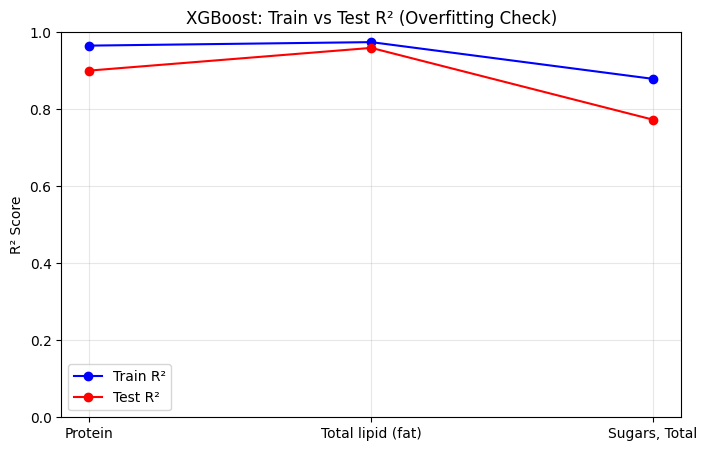

In [ ]:
import matplotlib.pyplot as plt

# Compute R² for each target
targets = ["Protein", "Total lipid (fat)", "Sugars, Total"]

r2_train = [r2_score(y_train[target], y_pred_xgb_train[:, i]) for i, target in enumerate(targets)]
r2_test  = [r2_score(y_test[target], y_pred_xgb_test[:, i]) for i, target in enumerate(targets)]

# Plot
plt.figure(figsize=(8,5))
plt.plot(targets, r2_train, marker='o', label='Train R²', color='blue')
plt.plot(targets, r2_test, marker='o', label='Test R²', color='red')

plt.title("XGBoost: Train vs Test R² (Overfitting Check)")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Interpretation:**

For protein thelines are very close which means there is very low overfitting  the model predicts protein well on unseen data.for total lipid (fat) The lines almost overlap completely meaning there is almost no overfitting which meansthe model generalizes extremely well.For Sugars, there is a
noticeable gap between train and test R² meaning a slight overfitting, explained by high variation in sugar content among different foods Inconsistent values, making it harder for the model to capture all patterns perfectly

 ### 1.5 Linear Regression
#### 1.5.1 Model Training

In [ ]:
from sklearn.linear_model import LinearRegression
#we use MultiOutputRegressor to wrap single-output model to handle multiple targets
# Train Linear Regression
lr = MultiOutputRegressor(LinearRegression())
lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test  = lr.predict(X_test)


#### 1.5.2 Model Evaluation

In [ ]:
print("\nTraining Performance")
evaluate(y_train, y_pred_lr_train,"LinearRegression")

print("\nTesting Performance")
evaluate(y_test, y_pred_lr_test, "LinearRegression")


Training Performance
LinearRegression

Protein
R²  : 0.801
MAE : 2.813
RMSE: 4.806

Total lipid (fat)
R²  : 0.913
MAE : 2.821
RMSE: 4.792

Sugars, Total
R²  : 0.575
MAE : 4.826
RMSE: 8.645

Testing Performance
LinearRegression

Protein
R²  : 0.737
MAE : 2.868
RMSE: 5.735

Total lipid (fat)
R²  : 0.886
MAE : 2.883
RMSE: 5.683

Sugars, Total
R²  : 0.612
MAE : 4.998
RMSE: 8.588


**Interpretation**
Linear Regression: Linear Regression achieves Test R²=0.737 for Protein and 0.886 for Fat. The small train-test gap confirms low overfitting, however the model shows signs of underfitting because even on training data it only reaches R²=0.801 for Protein, meaning it's not catching the complexity of nutrient relationships. Sugar at R²=0.612 with MAE=4.998g confirms the model's limitation on the most non-linear target.

 ### 1.6 Models Comparaison

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

all_results = []

def add_results(model_name, y_pred, y_true):
    for i, target in enumerate(targets):
        mae  = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        r2   = r2_score(y_true.iloc[:, i], y_pred[:, i])
        all_results.append({
            'Model':  model_name,
            'Target': target,
            'R²':     round(r2, 4),
            'MAE':    round(mae, 4),
            'RMSE':   round(rmse, 4),
        })

add_results('Linear Regression', y_pred_lr_test,  y_test)
add_results('Random Forest',     y_pred_rf,  y_test)
add_results('Gradient Boosting', y_pred_gb_test,  y_test)
add_results('XGBoost',           y_pred_xgb_test, y_test)
add_results('SVR RBF',           y_pred_svr,      y_test)

df_results = pd.DataFrame(all_results)

# Table per target
for target in targets:
    print(f"\n{'='*55}")
    print(f" {target}")
    print(f"{'='*55}")
    sub = df_results[df_results['Target'] == target]\
          .sort_values('R²', ascending=False)\
          .reset_index(drop=True)
    print(sub[['Model', 'R²', 'MAE', 'RMSE']].to_string(index=False))

# Overall ranking
print(f"\n{'='*55}")
print(" RANKING BY AVERAGE R²")
print(f"{'='*55}")
summary = df_results.groupby('Model').agg(
    Avg_R2=('R²',   'mean'),
    Avg_MAE=('MAE',  'mean'),
    Avg_RMSE=('RMSE','mean'),
).round(4).sort_values('Avg_R2', ascending=False)
print(summary.to_string())


 Protein
            Model     R²    MAE   RMSE
Gradient Boosting 0.9099 1.7119 3.3583
    Random Forest 0.9082 1.3427 3.3915
          XGBoost 0.9005 1.7269 3.5295
          SVR RBF 0.8866 1.8045 3.7689
Linear Regression 0.7374 2.8680 5.7349

 Total lipid (fat)
            Model     R²    MAE   RMSE
Gradient Boosting 0.9610 1.9728 3.3270
    Random Forest 0.9600 1.6096 3.3678
          XGBoost 0.9594 2.0072 3.3935
          SVR RBF 0.9273 2.0890 4.5425
Linear Regression 0.8863 2.8829 5.6825

 Sugars, Total
            Model     R²    MAE   RMSE
          XGBoost 0.7730 3.0996 6.5672
Gradient Boosting 0.7660 3.1220 6.6670
    Random Forest 0.7536 2.7495 6.8419
          SVR RBF 0.7536 3.2776 6.8415
Linear Regression 0.6117 4.9980 8.5879

 RANKING BY AVERAGE R²
                   Avg_R2  Avg_MAE  Avg_RMSE
Model                                       
Gradient Boosting  0.8790   2.2689    4.4508
XGBoost            0.8776   2.2779    4.4967
Random Forest      0.8739   1.9006    4.5337
SVR

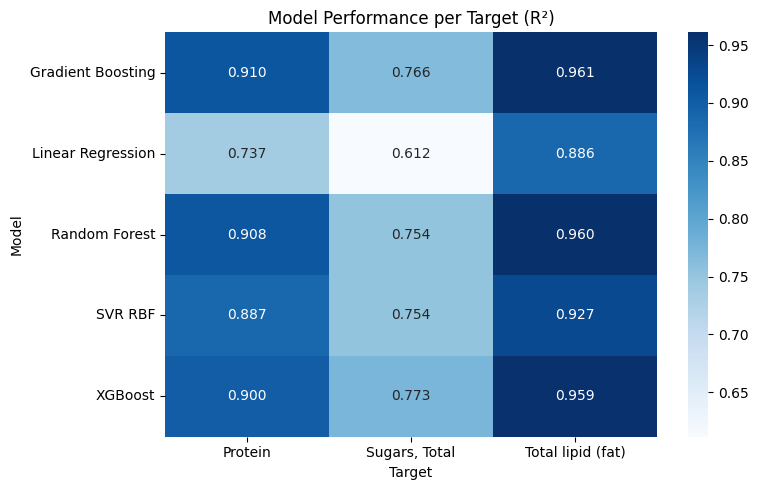

In [ ]:
import seaborn as sns


plt.figure(figsize=(8,5))

pivot = df_results.pivot_table(
    index="Model",
    columns="Target",
    values="R²"
)

sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".3f")

plt.title("Model Performance per Target (R²)")
plt.tight_layout()
plt.show()

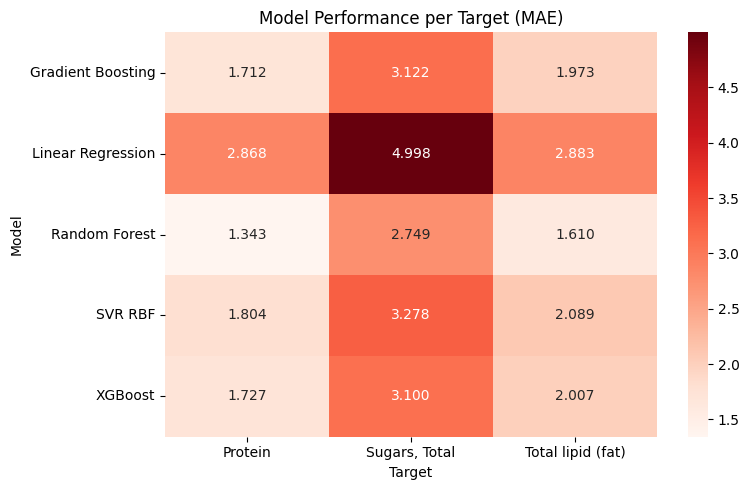

In [ ]:

plt.figure(figsize=(8,5))

pivot_mae = df_results.pivot_table(
    index="Model",
    columns="Target",
    values="MAE"
)

sns.heatmap(pivot_mae, annot=True, cmap="Reds", fmt=".3f")

plt.title("Model Performance per Target (MAE)")
plt.tight_layout()
plt.show()

XGBoost and Gradient Boosting showed very close performance. Gradient Boosting had slightly higher R², which means it generalized a bit better overall, while XGBoost outperformed it on the sugars target
,Random Forest also showed strong performance but with higher overfitting compared to the others
SVR and Linear Regression showed lower performance.

To find the best model between the two boosters,we're going to do cross validation and hyperparametere tuning using randomized search

 ### 1.7 Cross Validation

 #### 1.7.1 Gradient Boost

In [ ]:
from sklearn.model_selection import cross_val_score
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']

print("="*50)
print("5-FOLD CROSS VALIDATION — Gradient Boosting")
print("="*50)

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

for i, target in enumerate(targets):

    scores = cross_val_score(
        model,
        X,
        y[target],
        cv=5,
        scoring='r2'
    )

    print(f"\n{target}")
    print(f"R² per fold : {[round(s,3) for s in scores]}")
    print(f"Mean R²     : {scores.mean():.3f}")
    print(f"Std         : {scores.std():.3f}")
    print(f"Test R²     : {r2_score(y_test[target], y_pred_gb_test[:, i]):.4f}")

5-FOLD CROSS VALIDATION — Gradient Boosting

Protein
R² per fold : [np.float64(0.867), np.float64(0.86), np.float64(0.938), np.float64(0.873), np.float64(0.921)]
Mean R²     : 0.892
Std         : 0.031
Test R²     : 0.9099

Total lipid (fat)
R² per fold : [np.float64(0.892), np.float64(0.884), np.float64(0.959), np.float64(0.971), np.float64(0.879)]
Mean R²     : 0.917
Std         : 0.040
Test R²     : 0.9610

Sugars, Total
R² per fold : [np.float64(0.73), np.float64(0.708), np.float64(0.643), np.float64(0.731), np.float64(0.717)]
Mean R²     : 0.706
Std         : 0.033
Test R²     : 0.7660


**Interpretation:**
The 5-fold cross-validation results show that the Gradient Boosting model performs consistently across different data splits.The average cross-validation R² values are close to the test R² values shows that there is no significant overfitting. The model performs well for Protein and Total lipid (fat), while performance on Sugars remains lower ,The small std across folds indicate stable model performance.


 #### 1.7.2 XGBOOST

In [ ]:

print("="*50)
print("5-FOLD CROSS VALIDATION — XGBoost")
print("="*50)

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

for i, target in enumerate(targets):

    scores = cross_val_score(
        model,
        X,
        y[target],
        cv=5,
        scoring='r2'
    )

    print(f"\n{target}")
    print(f"R2 per fold : {[round(s,3) for s in scores]}")
    print(f"Mean R2     : {scores.mean():.3f}")
    print(f"Std         : {scores.std():.3f}")
    print(f"Test R2     : {r2_score(y_test[target], y_pred_xgb_test[:, i]):.4f}")

5-FOLD CROSS VALIDATION — XGBoost

Protein
R2 per fold : [np.float64(0.859), np.float64(0.866), np.float64(0.937), np.float64(0.874), np.float64(0.91)]
Mean R2     : 0.889
Std         : 0.030
Test R2     : 0.9005

Total lipid (fat)
R2 per fold : [np.float64(0.904), np.float64(0.88), np.float64(0.956), np.float64(0.97), np.float64(0.885)]
Mean R2     : 0.919
Std         : 0.037
Test R2     : 0.9594

Sugars, Total
R2 per fold : [np.float64(0.744), np.float64(0.71), np.float64(0.651), np.float64(0.733), np.float64(0.693)]
Mean R2     : 0.706
Std         : 0.033
Test R2     : 0.7730


**Interpretation:**
XGBoost shows strong performance for predicting Protein and Total Lipid (Fat) ,sugars are harder to predict but overall, XGBoost generalizes well


 #### 1.7.3 Comparaison

In [ ]:

results = {
    "Gradient Boosting": {
        "Protein": {"CV_R2": 0.8918, "Test_R2": 0.9099},
        "Total Lipid (Fat)": {"CV_R2": 0.9170, "Test_R2": 0.9610},
        "Sugars, Total": {"CV_R2": 0.7059, "Test_R2": 0.7660}
    },
    "XGBoost": {
        "Protein": {"CV_R2": 0.8891, "Test_R2": 0.9005},
        "Total Lipid (Fat)": {"CV_R2": 0.9190, "Test_R2": 0.9594},
        "Sugars, Total": {"CV_R2": 0.7062, "Test_R2": 0.7730}
    }
}

# Transform dictionary to a DataFrame
rows = []
for model, targets in results.items():
    for target, metrics in targets.items():
        gap = metrics["Test_R2"] - metrics["CV_R2"]
        rows.append({
            "Model": model,
            "Target": target,
            "CV_R2": metrics["CV_R2"],
            "Test_R2": metrics["Test_R2"],
            "Gap": gap
        })

comparison_df = pd.DataFrame(rows)

# Sort nicely
comparison_df = comparison_df.sort_values(by=["Target", "Model"]).reset_index(drop=True)
comparison_df

,Model,Target,CV_R2,Test_R2,Gap
0,Gradient Boosting,Protein,0.8918,0.9099,0.0181
1,XGBoost,Protein,0.8891,0.9005,0.0114
2,Gradient Boosting,"Sugars, Total",0.7059,0.7660,0.0601
3,XGBoost,"Sugars, Total",0.7062,0.7730,0.0668
4,Gradient Boosting,Total Lipid (Fat),0.9170,0.9610,0.0440
5,XGBoost,Total Lipid (Fat),0.9190,0.9594,0.0404


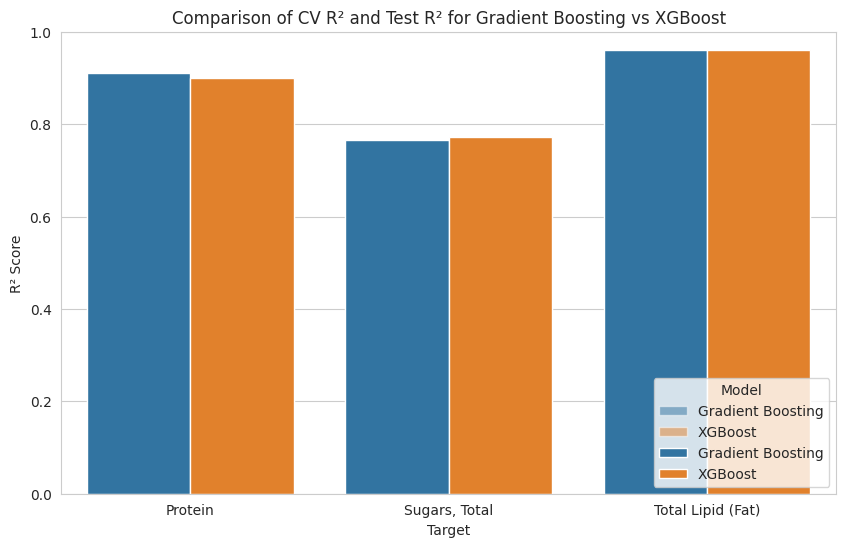

In [ ]:

sns.set_style("whitegrid")

# Convert DataFrame to long format
df_long = comparison_df.melt(
    id_vars=["Target", "Model"],
    value_vars=["CV_R2", "Test_R2"],
    var_name="Metric",
    value_name="R2"
)

plt.figure(figsize=(10,6))

# Plot CV_R2 first
for metric, alpha in zip(["CV_R2","Test_R2"], [0.5, 1.0]):
    subset = df_long[df_long["Metric"] == metric]
    sns.barplot(
        data=subset, x="Target", y="R2", hue="Model",
        alpha=alpha, errorbar=None, dodge=True
    )

plt.title("Comparison of CV R² and Test R² for Gradient Boosting vs XGBoost")
plt.ylabel("R² Score")
plt.ylim(0, 1)

# Adjust legend manually
plt.legend(title="Model", loc="lower right")
plt.show()

Although Gradient Boosting shows slightly higher R² in some train/test results, both Gradient Boosting and XGBoost achieve very similar performance overall.Cross-validation results indicate that XGBoost shows slightly better results on the more difficult Sugars target.

 ### 1.8 Hyperparameter tuning

 #### 1.8.1 Gradient Boost

The code below is first try it took long time

In [ ]:
'''from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'estimator__n_estimators': [50, 100, 200, 300],
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 4, 5, 6],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__subsample': [0.7, 0.8, 0.9, 1.0]
}

gb_multi = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))

random_search = RandomizedSearchCV(
    estimator=gb_multi,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print("Best parameters found:")
print(random_search.best_params_)
print(f"\nBest CV R²: {random_search.best_score_:.4f}")'''

'from sklearn.model_selection import RandomizedSearchCV\n\nparam_distributions = {\n    \'estimator__n_estimators\': [50, 100, 200, 300],\n    \'estimator__learning_rate\': [0.01, 0.05, 0.1, 0.2],\n    \'estimator__max_depth\': [3, 4, 5, 6],\n    \'estimator__min_samples_split\': [2, 5, 10],\n    \'estimator__subsample\': [0.7, 0.8, 0.9, 1.0]\n}\n\ngb_multi = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))\n\nrandom_search = RandomizedSearchCV(\n    estimator=gb_multi,\n    param_distributions=param_distributions,\n    n_iter=20,\n    cv=5,\n    scoring=\'r2\',\n    random_state=42,\n    n_jobs=-1,\n    verbose=1\n)\n\nrandom_search.fit(X_train_scaled, y_train)\n\nprint("Best parameters found:")\nprint(random_search.best_params_)\nprint(f"\nBest CV R²: {random_search.best_score_:.4f}")'

In [ ]:
"""from sklearn.model_selection import RandomizedSearchCV
import joblib

param_distributions = {
    'estimator__n_estimators':      [100, 200, 300],
    'estimator__learning_rate':     [0.05, 0.1, 0.2],
    'estimator__max_depth':         [3, 4, 5],
    'estimator__subsample':         [0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.4f}")


joblib.dump(random_search, 'random_search_gb.pkl')
print("Saved to random_search_gb.pkl")"""

'from sklearn.model_selection import RandomizedSearchCV\nimport joblib\n\nparam_distributions = {\n    \'estimator__n_estimators\':      [100, 200, 300],\n    \'estimator__learning_rate\':     [0.05, 0.1, 0.2],\n    \'estimator__max_depth\':         [3, 4, 5],\n    \'estimator__subsample\':         [0.8, 0.9, 1.0],\n}\n\nrandom_search = RandomizedSearchCV(\n    estimator=MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),\n    param_distributions=param_distributions,\n    n_iter=20,\n    cv=3,\n    scoring=\'r2\',\n    n_jobs=-1,\n    verbose=1,\n    random_state=42\n)\n\nrandom_search.fit(X_train, y_train)\n\nprint("Best parameters:")\nprint(random_search.best_params_)\nprint(f"Best CV R²: {random_search.best_score_:.4f}")\n\n\njoblib.dump(random_search, \'random_search_gb.pkl\')\nprint("Saved to random_search_gb.pkl")'



---




Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
subsample: 0.9,
n_estimators: 200,
max_depth: 5,
learning_rate: 0.1

Best CV R²: 0.8770


 ### Training with tuned gradient boost



for taining with best parameter
max-depth=5: risk of overfitting
max-depth=3: risk of underfitting
max-depth=4: balance particulary for fat and proteine

that's why i changed max-depth to 4

In [ ]:
# Best parameters found from RandomizedSearch
best_params = {
    'n_estimators':      200,
    'learning_rate':     0.1,
    'max_depth':         4,
    'subsample':         0.9,
}


gb_tuned = MultiOutputRegressor(GradientBoostingRegressor(
    **best_params,
    random_state=42
))

gb_tuned.fit(X_train, y_train)

y_pred_tuned_train = gb_tuned.predict(X_train)
y_pred_tuned_test  = gb_tuned.predict(X_test)

print("Training Performance")
evaluate(y_train, y_pred_tuned_train, "GB Tuned")

print("\nTesting Performance")
evaluate(y_test, y_pred_tuned_test, "GB Tuned")

Training Performance
GB Tuned

Protein
R²  : 0.981
MAE : 1.026
RMSE: 1.468

Total Lipid (Fat)
R²  : 0.987
MAE : 1.259
RMSE: 1.865

Sugars, Total
R²  : 0.941
MAE : 1.777
RMSE: 3.216

Testing Performance
GB Tuned

Protein
R²  : 0.930
MAE : 1.495
RMSE: 2.965

Total Lipid (Fat)
R²  : 0.967
MAE : 1.731
RMSE: 3.081

Sugars, Total
R²  : 0.782
MAE : 2.965
RMSE: 6.435


In [ ]:

data = {
    "Target": ["Protein", "Total Lipid (Fat)", "Sugars, Total"],
    "Train R²": [0.981, 0.987, 0.941],
    "Test R²": [0.930, 0.967, 0.78]
}

df = pd.DataFrame(data)

# Calculate Overfitting Gap
df["Gap"] = df["Train R²"] - df["Test R²"]
def overfit_level(gap):
    if gap < 0.02:
        return "Low"
    elif gap < 0.10:
        return "Moderate"
    else:
        return "High"

df["Overfitting Level"] = df["Gap"].apply(overfit_level)
# Round values
df = df.round(3)

print(df)

              Target  Train R²  Test R²    Gap Overfitting Level
0            Protein     0.981    0.930  0.051          Moderate
1  Total Lipid (Fat)     0.987    0.967  0.020          Moderate
2      Sugars, Total     0.941    0.780  0.161              High


In [ ]:
df

,Target,Train R²,Test R²,Gap,Overfitting Level
0,Protein,0.981,0.930,0.051,Moderate
1,Total Lipid (Fat),0.987,0.967,0.020,Moderate
2,"Sugars, Total",0.941,0.780,0.161,High


**Overfitting Check**

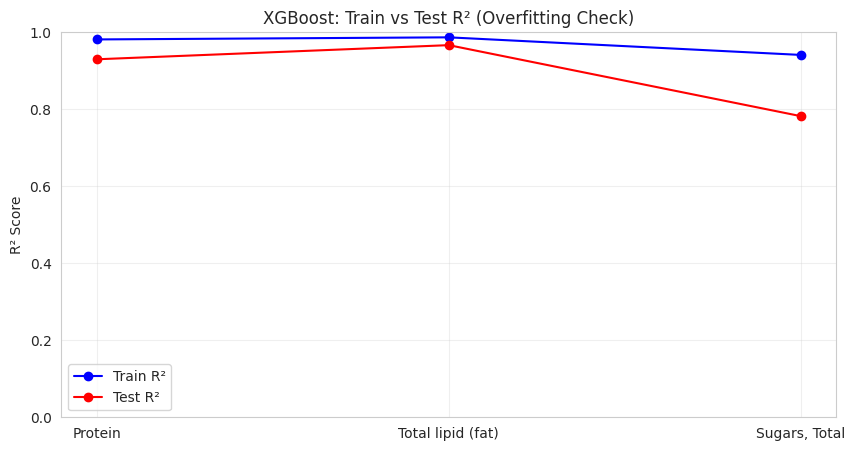

In [ ]:


# Compute R² for each target
targets = ["Protein", "Total lipid (fat)", "Sugars, Total"]

r2_train = [r2_score(y_train[target], y_pred_tuned_train[:, i]) for i, target in enumerate(targets)]
r2_test  = [r2_score(y_test[target], y_pred_tuned_test[:, i]) for i, target in enumerate(targets)]

# Plot
plt.figure(figsize=(10,5))
plt.plot(targets, r2_train, marker='o', label='Train R²', color='blue')
plt.plot(targets, r2_test, marker='o', label='Test R²', color='red')

plt.title("XGBoost: Train vs Test R² (Overfitting Check)")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

After hyperparameter tuning, the Gradient Boosting model shows improved performance for Protein and Total Lipid (Fat), with higher test R², slightly reduced overfitting for Protein, and a negligible increase in overfitting for Fat. However, for Sugars, although the test performance improved slightly, the model exhibits higher overfitting. Overall, the tuned model provides better results for Protein and Fat, but does not improve performance for Sugars.

#### **Cross Validation for tuned gradient boost model**

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor

print("="*55)
print("5-FOLD CROSS VALIDATION — Gradient Boosting Tuned")
print("="*55)

cv_results = {}

for i, target in enumerate(targets):

    gb_single = GradientBoostingRegressor(**best_params, random_state=42)

    scores = cross_validate(
        gb_single,
        X, y[target],
        cv=5,
        scoring=['r2', 'neg_mean_absolute_error'],
        return_train_score=True
    )

    cv_results[target] = scores

    print(f"\n{target}")
    print(f"R2 per fold : {[round(s,3) for s in scores['test_r2']]}")
    print(f"Mean R2     : {scores['test_r2'].mean():.3f}")
    print(f"Std         : {scores['test_r2'].std():.3f}")
    print(f"Test R2     : {r2_score(y_test[target], y_pred_tuned_test[:, i]):.4f}")

5-FOLD CROSS VALIDATION — Gradient Boosting Tuned

Protein
R2 per fold : [np.float64(0.883), np.float64(0.866), np.float64(0.946), np.float64(0.887), np.float64(0.927)]
Mean R2     : 0.902
Std         : 0.030
Test R2     : 0.9298

Total lipid (fat)
R2 per fold : [np.float64(0.914), np.float64(0.889), np.float64(0.962), np.float64(0.978), np.float64(0.9)]
Mean R2     : 0.929
Std         : 0.035
Test R2     : 0.9666

Sugars, Total
R2 per fold : [np.float64(0.741), np.float64(0.708), np.float64(0.716), np.float64(0.753), np.float64(0.729)]
Mean R2     : 0.729
Std         : 0.016
Test R2     : 0.7820


cross-validation confirms that the tuned model generalizes well, with reliable and stable performance across different data splits.


 #### 1.8.2 Gradient Boost

In [ ]:
"""
param_distributions = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__learning_rate': [0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 4, 5],
    'estimator__subsample': [0.8, 0.9, 1.0],
    'estimator__colsample_bytree': [0.8, 0.9, 1.0],  # XGBoost specific
}

random_search_xgb = RandomizedSearchCV(
    estimator=MultiOutputRegressor(
        XGBRegressor(
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
    ),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

print("Best parameters:")
print(random_search_xgb.best_params_)
print(f"Best CV R²: {random_search_xgb.best_score_:.4f}")

# Save model
joblib.dump(random_search_xgb, 'random_search_xgb.pkl')
print("Saved to random_search_xgb.pkl")"""

'\nparam_distributions = {\n    \'estimator__n_estimators\': [100, 200, 300],\n    \'estimator__learning_rate\': [0.05, 0.1, 0.2],\n    \'estimator__max_depth\': [3, 4, 5],\n    \'estimator__subsample\': [0.8, 0.9, 1.0],\n    \'estimator__colsample_bytree\': [0.8, 0.9, 1.0],  # XGBoost specific\n}\n\nrandom_search_xgb = RandomizedSearchCV(\n    estimator=MultiOutputRegressor(\n        XGBRegressor(\n            random_state=42,\n            n_jobs=-1,\n            verbosity=0\n        )\n    ),\n    param_distributions=param_distributions,\n    n_iter=20,\n    cv=3,\n    scoring=\'r2\',\n    n_jobs=-1,\n    verbose=1,\n    random_state=42\n)\n\nrandom_search_xgb.fit(X_train, y_train)\n\nprint("Best parameters:")\nprint(random_search_xgb.best_params_)\nprint(f"Best CV R²: {random_search_xgb.best_score_:.4f}")\n\n# Save model\njoblib.dump(random_search_xgb, \'random_search_xgb.pkl\')\nprint("Saved to random_search_xgb.pkl")'

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
subsample: 0.8,
n_estimators: 300,
max_depth: 5
learning_rate: 0.05, colsample_bytree': 0.8
Best CV R²: 0.8787


the slight decrease in cross-validation performance after Randomized Search is expected, as the tuning process may introduce more regularization and reduce overfitting. This often results in more stable and generalizable models, even if the validation score is marginally lower

 ### Training with tuned XGboost


In [ ]:

# Best parameters from RandomizedSearch
best_params_xgb = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

# Create model
xgb_tuned = MultiOutputRegressor(
    XGBRegressor(
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
    )
)

# Train
xgb_tuned.fit(X_train, y_train)

# Predict
y_pred_xgb_train_tuned = xgb_tuned.predict(X_train)
y_pred_xgb_test_tuned  = xgb_tuned.predict(X_test)

# Evaluate
print("Training Performance")
evaluate(y_train, y_pred_xgb_train_tuned, "XGB Tuned")

print("\nTesting Performance")
evaluate(y_test, y_pred_xgb_test_tuned, "XGB Tuned")

Training Performance
XGB Tuned

Protein
R²  : 0.986
MAE : 0.867
RMSE: 1.268

Total lipid (fat)
R²  : 0.990
MAE : 1.085
RMSE: 1.650

Sugars, Total
R²  : 0.962
MAE : 1.378
RMSE: 2.590

Testing Performance
XGB Tuned

Protein
R²  : 0.919
MAE : 1.432
RMSE: 3.188

Total lipid (fat)
R²  : 0.965
MAE : 1.640
RMSE: 3.133

Sugars, Total
R²  : 0.777
MAE : 2.747
RMSE: 6.503


**Overfitting Check**

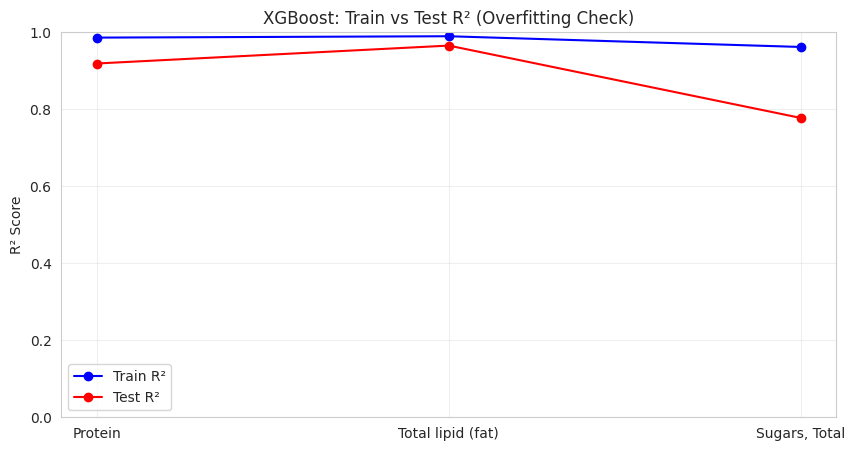

In [ ]:
import matplotlib.pyplot as plt

# Compute R² for each target
targets = ["Protein", "Total lipid (fat)", "Sugars, Total"]

r2_train = [r2_score(y_train[target], y_pred_xgb_train_tuned [:, i]) for i, target in enumerate(targets)]
r2_test  = [r2_score(y_test[target], y_pred_xgb_test_tuned [:, i]) for i, target in enumerate(targets)]

# Plot
plt.figure(figsize=(10,5))
plt.plot(targets, r2_train, marker='o', label='Train R²', color='blue')
plt.plot(targets, r2_test, marker='o', label='Test R²', color='red')

plt.title("XGBoost: Train vs Test R² (Overfitting Check)")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

After hyperparameter tuning with RandomizedSearch XGBoost improved across all targets however it increased overfitting

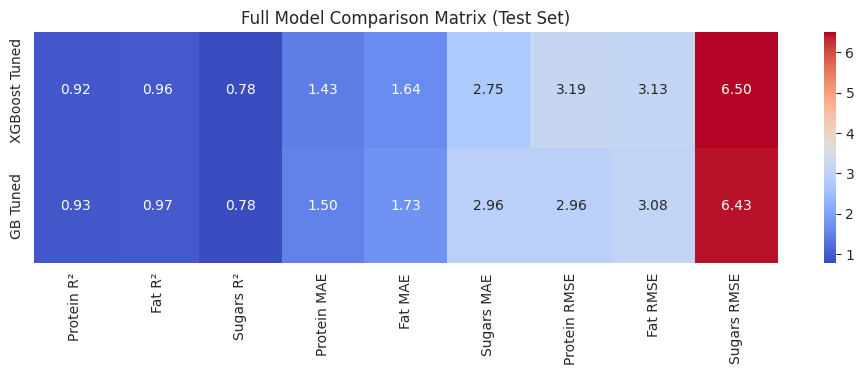

In [ ]:
df_all = pd.DataFrame({
    "Protein R²": [0.919, 0.930],
    "Fat R²": [0.965, 0.967],
    "Sugars R²": [0.777, 0.782],
    "Protein MAE": [1.432, 1.495],
    "Fat MAE": [1.640, 1.731],
    "Sugars MAE": [2.747, 2.965],
    "Protein RMSE": [3.188, 2.965],
    "Fat RMSE": [3.133, 3.081],
    "Sugars RMSE": [6.503, 6.435],
}, index=["XGBoost Tuned", "GB Tuned"])

plt.figure(figsize=(12,3))
sns.heatmap(df_all, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Full Model Comparison Matrix (Test Set)")
plt.show()

#Conclusion

After evaluating five models Linear Regression, SVR RBF, Random Forest, XGBoost and Gradient Boosting  and trying 2 of them with both with default and tuned hyperparameters, the final model selected is Gradient Boosting with tuned parameters ,It achieves the best test performance across all three targets, Compared to XGBoost Tuned .however,still Sugar remains the most hard target across all models caused by dataset limitation not models

### 1.9 feature importance on gradient boost

In [ ]:
target_names = ["Protein", "Total lipid (fat)", "Sugars, Total"]

for i, est in enumerate(gb_tuned.estimators_):
    print(f"\n=== {target_names[i]} ===")

    importances = est.feature_importances_

    feature_importance = list(zip(X.columns, importances))
    feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

    for feature, imp in feature_importance:
        print(f"Feature {feature}: {imp:.3f}")



=== Protein ===
Feature Phosphorus, P: 0.404
Feature Carbohydrate, by difference: 0.129
Feature Cholesterol: 0.122
Feature Zinc, Zn: 0.112
Feature Selenium, Se: 0.046
Feature Water: 0.038
Feature Niacin: 0.021
Feature Magnesium, Mg: 0.020
Feature Iron, Fe: 0.018
Feature Choline, total: 0.010
Feature Potassium, K: 0.010
Feature cat_Legumes and Legume Products: 0.008
Feature Copper, Cu: 0.007
Feature Ash: 0.007
Feature Riboflavin: 0.007
Feature cat_Beverages: 0.004
Feature Thiamin: 0.003
Feature Folate, total: 0.003
Feature cat_Snacks: 0.003
Feature Fiber, total dietary: 0.003
Feature Pantothenic acid: 0.003
Feature Vitamin B-6: 0.002
Feature Sodium, Na: 0.002
Feature Calcium, Ca: 0.002
Feature Vitamin C, total ascorbic acid: 0.002
Feature Manganese, Mn: 0.001
Feature Vitamin A, RAE: 0.001
Feature Vitamin B-12: 0.001
Feature cat_Cereal Grains and Pasta: 0.001
Feature Vitamin D (D2 + D3): 0.001
Feature Vitamin E (alpha-tocopherol): 0.001
Feature cat_Poultry Products: 0.001
Feature cat_Ba

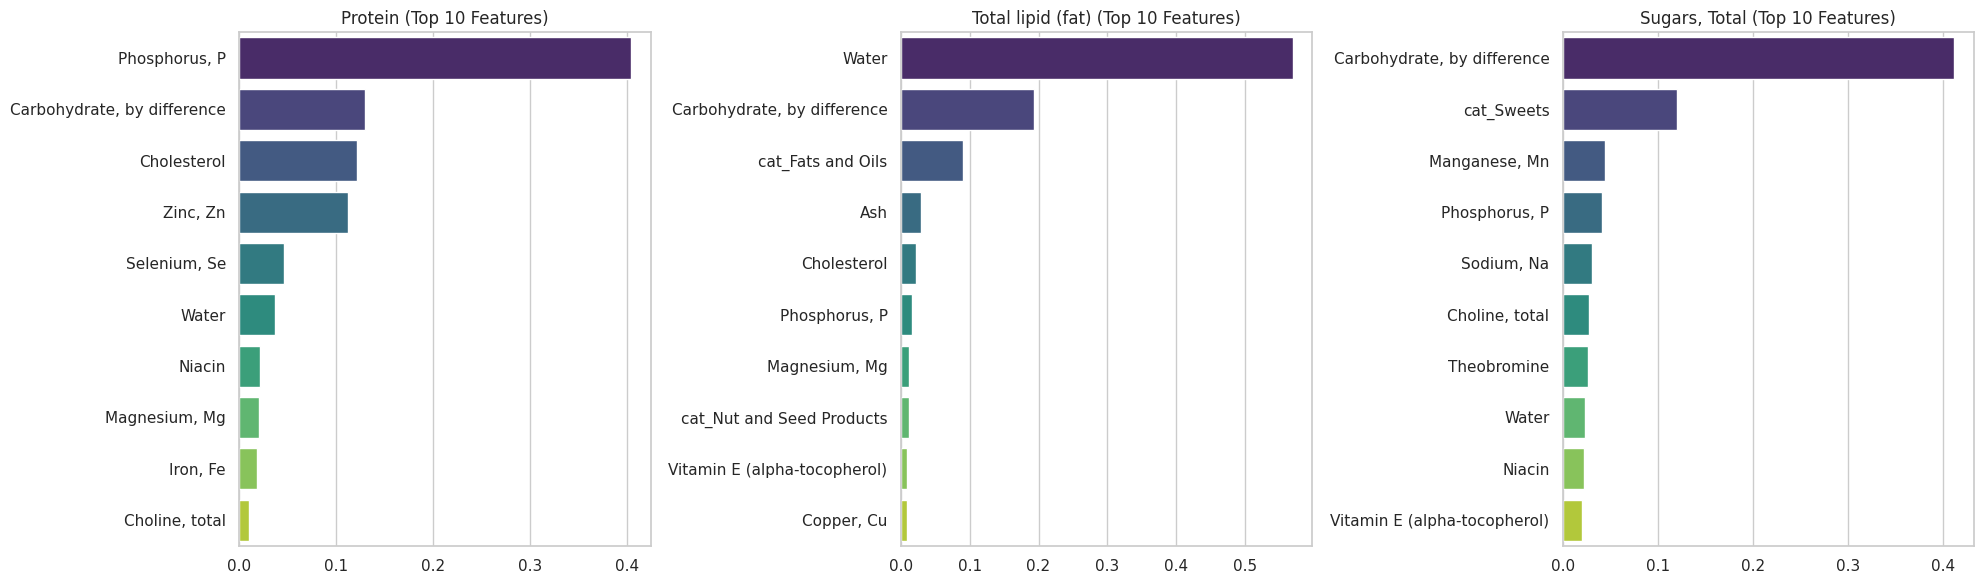

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, est in enumerate(gb_tuned.estimators_):

    importances = est.feature_importances_
    feature_importance = list(zip(X.columns, importances))
    feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

    top_features = feature_importance[:10]

    df_plot = pd.DataFrame(top_features, columns=["Feature", "Importance"])

    sns.barplot(
        data=df_plot,
        x="Importance",
        y="Feature",
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(target_names[i] + " (Top 10 Features)")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
#model evaluation with tuned parameters

selected_features= [
    # Protein top features
    "Phosphorus, P", "Carbohydrate, by difference", "Zinc, Zn", "Cholesterol",
    "Selenium, Se", "Water", "Magnesium, Mg", "Niacin","Iron, Fe",


    # fat top features
    "cat_Fats and Oils", "Water","Ash", "Cholesterol",
    "Carbohydrate, by difference",

    # Sugars top features
    "Carbohydrate, by difference", "cat_Sweets", "Manganese, Mn",
    "Phosphorus, P", "Sodium, Na", "Choline, total",

]
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

gb = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.9,
    random_state=42
))

# Train on selected features
gb.fit(X_train_sel, y_train)

# Predictions
y_pred_gb_train_imp = gb.predict(X_train_sel)
y_pred_gb_test_imp = gb.predict(X_test_sel)

# Evaluation
print("Training Performance")
print("="*30)
evaluate(y_train, y_pred_gb_train_imp, "Gradient Boosting - Train")

print("\nTesting Performance")
print("="*30)
evaluate(y_test, y_pred_gb_test_imp, "Gradient Boosting - Test")

Training Performance
Gradient Boosting - Train

Protein
R²  : 0.976
MAE : 1.155
RMSE: 1.667

Total lipid (fat)
R²  : 0.985
MAE : 1.325
RMSE: 1.973

Sugars, Total
R²  : 0.920
MAE : 2.083
RMSE: 3.749

Testing Performance
Gradient Boosting - Test

Protein
R²  : 0.911
MAE : 1.704
RMSE: 3.330

Total lipid (fat)
R²  : 0.959
MAE : 1.842
RMSE: 3.421

Sugars, Total
R²  : 0.749
MAE : 3.296
RMSE: 6.900


In [ ]:
test_data = pd.DataFrame({
    "Target": ["Protein", "Total fat", "Sugars"],
    "R²": [0.911, 0.959, 0.749],
    "MAE": [1.704, 1.842, 3.296],
    "RMSE": [3.330, 3.421, 6.900]
})

display(test_data)

,Target,R²,MAE,RMSE
0,Protein,0.911,1.704,3.330
1,Total fat,0.959,1.842,3.421
2,Sugars,0.749,3.296,6.900


Feature importance doesn't improve model performance but still results are very close to the full model which means later on for deployment we can focus on just those features

1.10 Residual & Actual vs Predicted GB

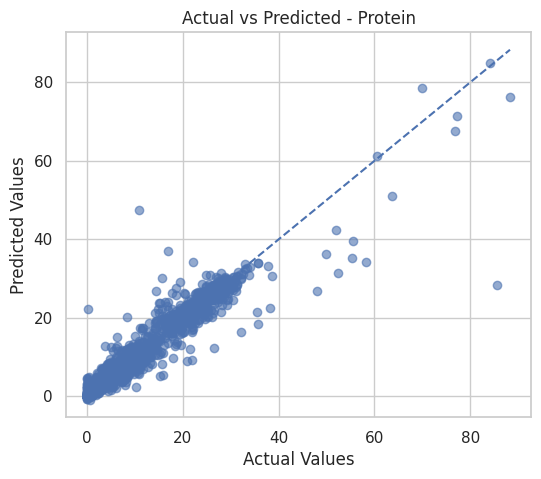

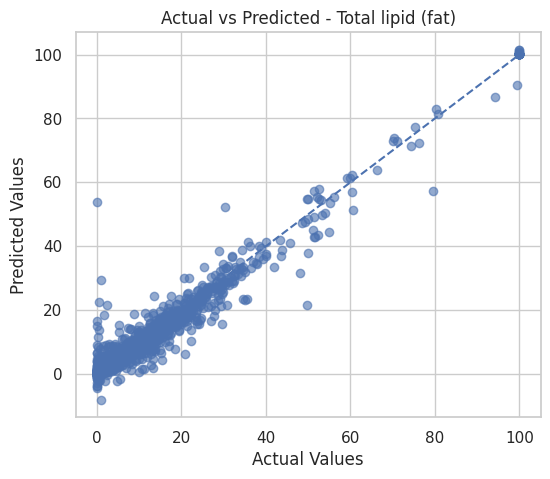

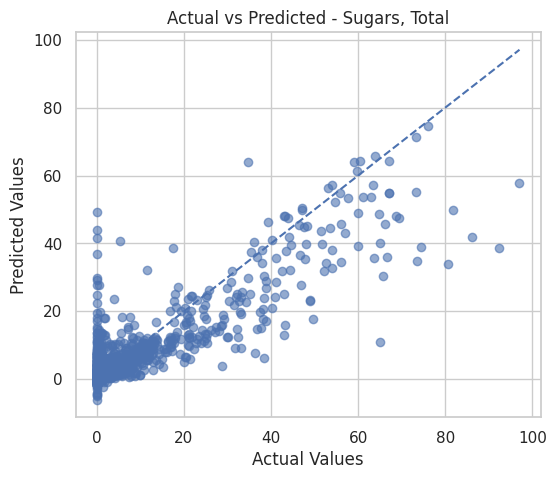

In [ ]:


# Loop through each target
for i, target in enumerate(targets):

    plt.figure(figsize=(6,5))

    # Scatter plot
    plt.scatter(y_test.iloc[:, i], y_pred_gb_test_imp[:, i],alpha=0.6)

    # Perfect prediction line
    plt.plot(
        [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
        [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
        linestyle="--"
    )

    plt.title(f"Actual vs Predicted - {target}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")

    plt.show()

In this plot, the dashed line represents perfect prediction. Points close to this line indicate accurate predictions. For Protein and Fat, points cluster closely around the diagonal confirming high R² scores. For Sugar, points scatter a bit widely especially for high values that's what explaines the lower R square, indicating the model struggles to predict high-sugar foods accurately

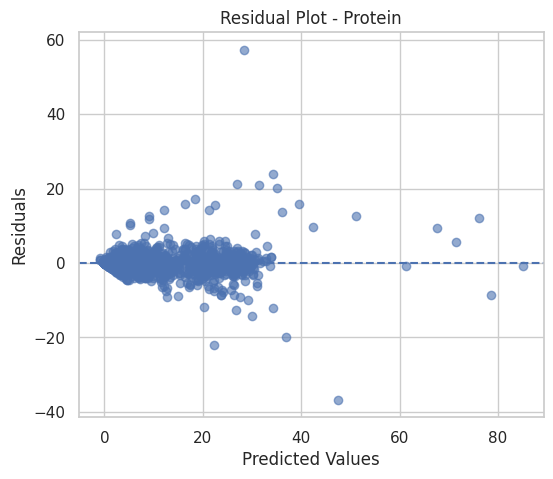

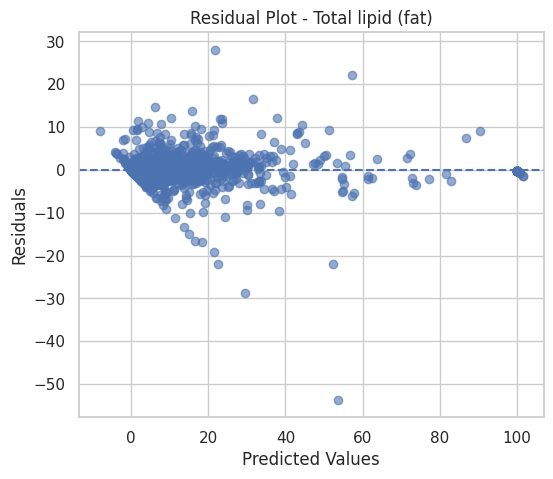

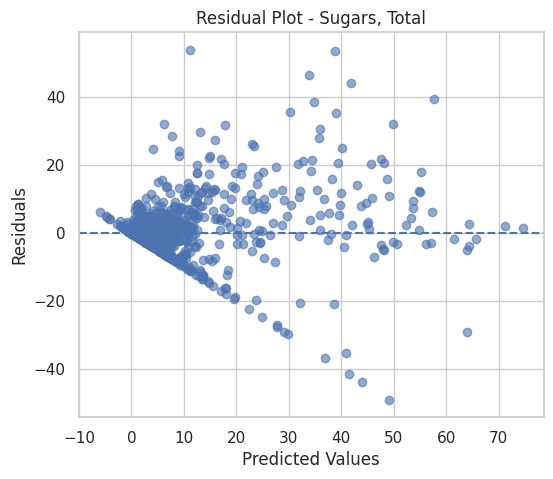

In [ ]:
for i, target in enumerate(targets):

    residuals = y_test.iloc[:, i] - y_pred_gb_test_imp[:, i]

    plt.figure(figsize=(6,5))

    plt.scatter(y_pred_gb_test_imp[:, i], residuals ,alpha =0.6)

    # Zero line
    plt.axhline(y=0, linestyle="--")

    plt.title(f"Residual Plot - {target}")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")

    plt.show()

The residual plot for Protein and fat shows points scattered around zero with no visible pattern, confirming the model captures the relationship well. For Sugar, a fan shape is visible,errors increase for higher predicted values indicating the model is less reliable for high-sugar foods

### 2.Corrupted cleaned data
#### 2.1 data splitting

In [ ]:
from sklearn.model_selection import train_test_split
#specify the target variables
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
#x takes the all columns except the targets hese are our feature
X_corr= corrupted_food_dataset.drop(columns=targets)
#y takes our target variables
y_corr = corrupted_food_dataset[targets]
#we split data into train and test data with test size 0.2 which means 20% of data is for test
#we put random state as 42 which help us generate same data combination everytime
X_corr_train, X_corr_test, y_corr_train, y_corr_test = train_test_split(
    X_corr, y_corr, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)

X_train: (6234, 70)


### 2.1 Gradient Boost
#### 2.1.1 Model training

In [ ]:
gb = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
))

gb.fit(X_corr_train,y_corr_train)
y_pred_gb_train_corr = gb.predict(X_corr_train)
y_pred_gb_test_corr= gb.predict(X_corr_test)


#### 2.1.2 Model Evaluation

In [ ]:
print("Training Performance")
print("="*30)
evaluate(y_corr_train, y_pred_gb_train_corr, "Gradient Boosting - Train")

print("\nTesting Performance")
print("="*30)
evaluate(y_corr_test, y_pred_gb_test_corr, "Gradient Boosting - Test")

Training Performance
Gradient Boosting - Train

Protein
R²  : 0.892
MAE : 2.204
RMSE: 3.314

Total lipid (fat)
R²  : 0.866
MAE : 2.558
RMSE: 3.926

Sugars, Total
R²  : 0.560
MAE : 1.997
RMSE: 4.560

Testing Performance
Gradient Boosting - Test

Protein
R²  : 0.830
MAE : 2.671
RMSE: 4.160

Total lipid (fat)
R²  : 0.748
MAE : 3.219
RMSE: 5.509

Sugars, Total
R²  : 0.239
MAE : 2.411
RMSE: 5.603


The results show that the Gradient Boosting model shows moderate overfitting for Protein and Total Lipid (Fat), as for Sugars target shows a larger gap, indicating strong overfitting and poor generalization. Manual Hyperparameter tuning slightly improved the Sugars test performance and reduced the overfitting gap but it is still considered large.

### 2.2 Random forest
#### 2.2.1 Model training and evaluation

In [ ]:
rf = MultiOutputRegressor(
      RandomForestRegressor(
      n_estimators=200,
      random_state=42,
      max_depth=5,
      n_jobs=-1,
      min_samples_split=5,
      min_samples_leaf=2
  )
)

# Train model
rf.fit(X_corr_train, y_corr_train)

# Predict
y_pred_rf_corr = rf.predict(X_corr_test)
y_pred_train_corr = rf.predict(X_corr_train)

# Evaluate
evaluate(y_corr_train, y_pred_train_corr, "Random Forest - Train")
evaluate(y_corr_test, y_pred_rf_corr, "Random Forest - Test")

Random Forest - Train

Protein
R²  : 0.813
MAE : 2.966
RMSE: 4.358

Total lipid (fat)
R²  : 0.712
MAE : 3.541
RMSE: 5.761

Sugars, Total
R²  : 0.332
MAE : 2.531
RMSE: 5.621
Random Forest - Test

Protein
R²  : 0.788
MAE : 3.153
RMSE: 4.640

Total lipid (fat)
R²  : 0.666
MAE : 3.902
RMSE: 6.333

Sugars, Total
R²  : 0.213
MAE : 2.570
RMSE: 5.696



#### 2.2.2 Overfitting check

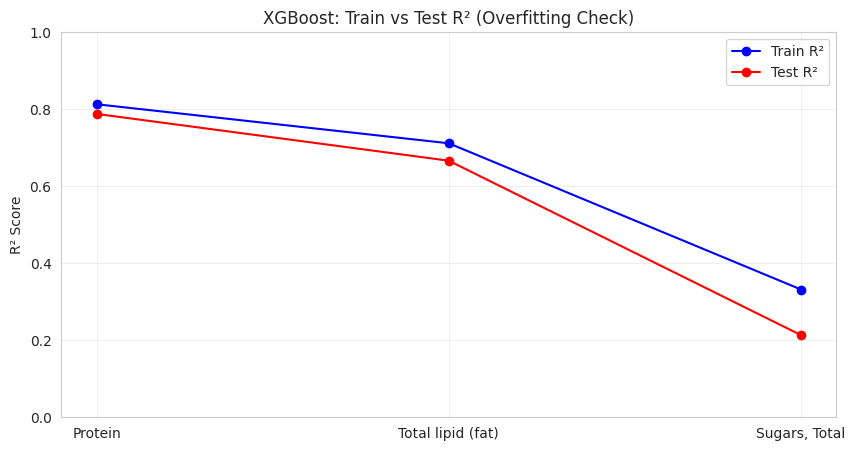

In [ ]:
import matplotlib.pyplot as plt

# Compute R² for each target
targets = ["Protein", "Total lipid (fat)", "Sugars, Total"]

r2_train = [
    r2_score(y_corr_train[target], y_pred_train_corr[:, i])
    for i, target in enumerate(targets)
]

r2_test = [
    r2_score(y_corr_test[target], y_pred_rf_corr[:, i])
    for i, target in enumerate(targets)
]

# Plot
plt.figure(figsize=(10,5))
plt.plot(targets, r2_train, marker='o', label='Train R²', color='blue')
plt.plot(targets, r2_test, marker='o', label='Test R²', color='red')

plt.title("XGBoost: Train vs Test R² (Overfitting Check)")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 2.3 XGBoost
#### 2.3.1 Model training and evaluation

In [ ]:

xgb = MultiOutputRegressor(XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_jobs=-1
))
xgb.fit(X_corr_train, y_corr_train)
y_pred_xgb_train_corr = xgb.predict(X_corr_train)
y_pred_xgb_test_corr  = xgb.predict(X_corr_test)
evaluate(y_corr_train, y_pred_xgb_train_corr, "XGBoost - Train")
evaluate(y_corr_test,  y_pred_xgb_test_corr,  "XGBoost - Test")

XGBoost - Train

Protein
R²  : 0.894
MAE : 2.137
RMSE: 3.289

Total lipid (fat)
R²  : 0.865
MAE : 2.501
RMSE: 3.938

Sugars, Total
R²  : 0.522
MAE : 1.998
RMSE: 4.756
XGBoost - Test

Protein
R²  : 0.831
MAE : 2.638
RMSE: 4.146

Total lipid (fat)
R²  : 0.767
MAE : 3.156
RMSE: 5.288

Sugars, Total
R²  : 0.252
MAE : 2.349
RMSE: 5.555


In [ ]:

data = {
    "Target": ["Protein", "Total Lipid (Fat)", "Sugars, Total"],
    "Train R²": [0.894, 0.865, 0.522],
    "Test R²": [0.831, 0.767, 0.252]
}

df = pd.DataFrame(data)

# Calculate Overfitting Gap
df["Gap"] = df["Train R²"] - df["Test R²"]
def overfit_level(gap):
    if gap < 0.02:
        return "Low"
    elif gap < 0.10:
        return "Moderate"
    else:
        return "High"

df["Overfitting Level"] = df["Gap"].apply(overfit_level)
# Round values
df = df.round(3)

print(df)

              Target  Train R²  Test R²    Gap Overfitting Level
0            Protein     0.894    0.831  0.063          Moderate
1  Total Lipid (Fat)     0.865    0.767  0.098          Moderate
2      Sugars, Total     0.522    0.252  0.270              High



#### 2.2.2 overfitting check

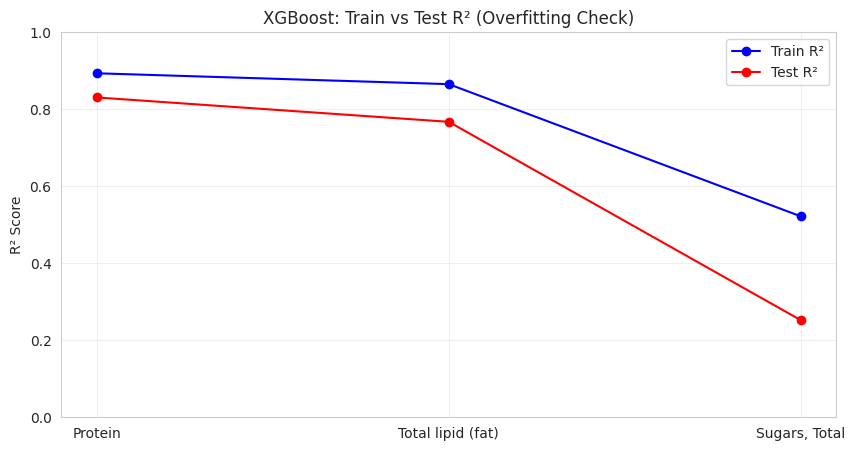

In [ ]:

# Compute R² for each target
targets = ["Protein", "Total lipid (fat)", "Sugars, Total"]

r2_train = [
    r2_score(y_corr_train[target], y_pred_xgb_train_corr[:, i])
    for i, target in enumerate(targets)
]

r2_test = [
    r2_score(y_corr_test[target], y_pred_xgb_test_corr[:, i])
    for i, target in enumerate(targets)
]

# Plot
plt.figure(figsize=(10,5))
plt.plot(targets, r2_train, marker='o', label='Train R²', color='blue')
plt.plot(targets, r2_test, marker='o', label='Test R²', color='red')

plt.title("XGBoost: Train vs Test R² (Overfitting Check)")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 2.3 Models Comparaison


In [ ]:
perf_results = []

def add_perf(model_name, y_pred, y_true):
    for i, target in enumerate(targets):
        mae  = mean_absolute_error(y_true[target], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[target], y_pred[:, i]))
        r2   = r2_score(y_true[target], y_pred[:, i])
        perf_results.append({
            'Model':  model_name,
            'Target': target,
            'R2':     round(r2, 4),
            'MAE':    round(mae, 4),
            'RMSE':   round(rmse, 4),
        })

add_perf('Random Forest',     y_pred_rf_corr,       y_corr_test)
add_perf('Gradient Boosting', y_pred_gb_test_corr,  y_corr_test)
add_perf('XGBoost',           y_pred_xgb_test_corr, y_corr_test)

df_perf = pd.DataFrame(perf_results)

# Table per target
for target in targets:
    print(f"\n{'='*55}")
    print(f" {target}")
    print(f"{'='*55}")
    sub = df_perf[df_perf['Target'] == target] \
          .sort_values('R2', ascending=False) \
          .reset_index(drop=True)
    print(sub[['Model', 'R2', 'MAE', 'RMSE']].to_string(index=False))

# Overall ranking
print(f"\n{'='*55}")
print(" RANKING BY AVERAGE R2")
print(f"{'='*55}")

summary_perf = df_perf.groupby('Model').agg(
    Avg_R2=('R2',   'mean'),
    Avg_MAE=('MAE',  'mean'),
    Avg_RMSE=('RMSE','mean'),
).round(4).sort_values('Avg_R2', ascending=False)

print(summary_perf.to_string())


 Protein
            Model     R2    MAE   RMSE
          XGBoost 0.8463 2.4906 3.9511
Gradient Boosting 0.8297 2.6706 4.1595
    Random Forest 0.7880 3.1531 4.6405

 Total lipid (fat)
            Model     R2    MAE   RMSE
          XGBoost 0.7649 3.0500 5.3166
Gradient Boosting 0.7476 3.2194 5.5086
    Random Forest 0.6664 3.9020 6.3329

 Sugars, Total
            Model     R2    MAE   RMSE
Gradient Boosting 0.2390 2.4113 5.6026
          XGBoost 0.2358 2.3964 5.6143
    Random Forest 0.2133 2.5699 5.6963

 RANKING BY AVERAGE R2
                   Avg_R2  Avg_MAE  Avg_RMSE
Model                                       
XGBoost            0.6157   2.6457    4.9607
Gradient Boosting  0.6054   2.7671    5.0902
Random Forest      0.5559   3.2083    5.5566


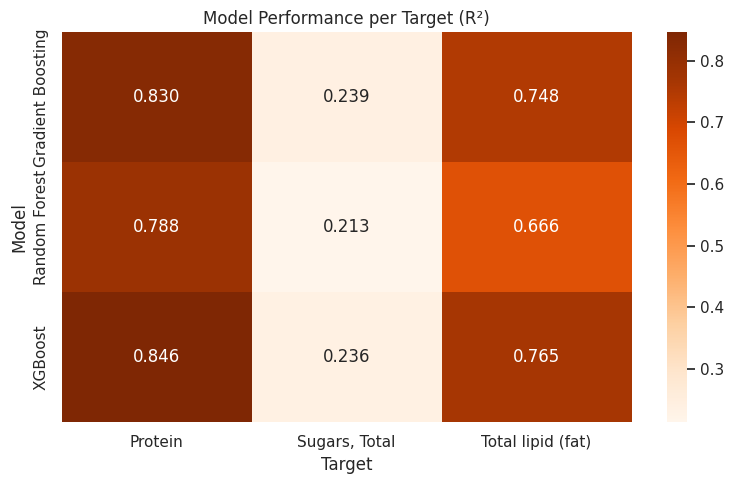

In [ ]:
plt.figure(figsize=(8,5))

pivot = df_perf.pivot_table(
    index="Model",
    columns="Target",
    values="R2"
)

sns.heatmap(pivot, annot=True, cmap="Oranges", fmt=".3f")

plt.title("Model Performance per Target (R²)")
plt.tight_layout()
plt.show()

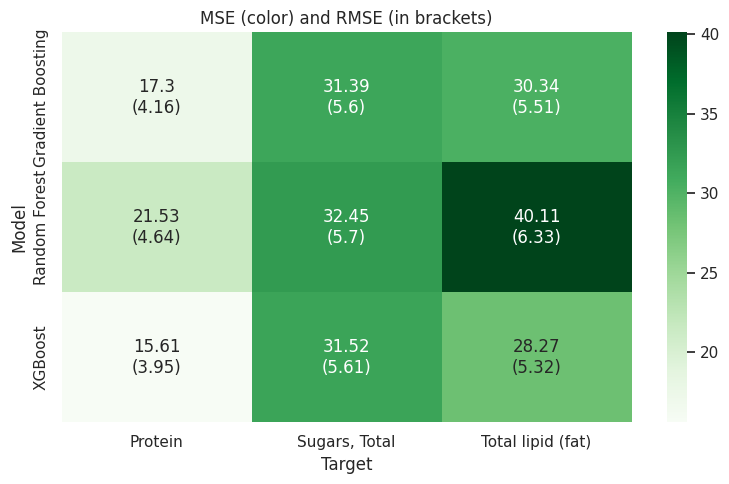

In [ ]:
# Create MSE
df_perf["MSE"] = df_perf["RMSE"] ** 2

# Create pivot tables
pivot_mse  = df_perf.pivot_table(index="Model", columns="Target", values="MSE")
pivot_rmse = df_perf.pivot_table(index="Model", columns="Target", values="RMSE")

# Combine into one annotation
annot = pivot_mse.round(2).astype(str) + "\n(" + pivot_rmse.round(2).astype(str) + ")"

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_mse,              # color based on MSE
    annot=annot,            # show both MSE and RMSE
    fmt="",
    cmap="Greens"
)

plt.title("MSE (color) and RMSE (in brackets)")
plt.tight_layout()
plt.show()

### 2.3 Cross validation for XGBOOST

In [ ]:

print("="*50)
print("5-FOLD CROSS VALIDATION — XGBoost")
print("="*50)

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

for i, target in enumerate(targets):

    scores = cross_val_score(
        model,
        X_corr,
        y_corr[target],
        cv=5,
        scoring='r2'
    )

    print(f"\n{target}")
    print(f"R2 per fold : {[round(s,3) for s in scores]}")
    print(f"Mean R2     : {scores.mean():.4f}")
    print(f"Std         : {scores.std():.4f}")
    print(f"Test R2     : {r2_score(y_corr_test[target], y_pred_xgb_test_corr[:, i]):.4f}")

5-FOLD CROSS VALIDATION — XGBoost

Protein
R2 per fold : [np.float64(0.661), np.float64(0.803), np.float64(0.859), np.float64(0.871), np.float64(0.855)]
Mean R2     : 0.8100
Std         : 0.0779
Test R2     : 0.8308

Total lipid (fat)
R2 per fold : [np.float64(0.764), np.float64(0.751), np.float64(0.744), np.float64(0.784), np.float64(0.751)]
Mean R2     : 0.7589
Std         : 0.0142
Test R2     : 0.7674

Sugars, Total
R2 per fold : [np.float64(0.243), np.float64(0.231), np.float64(0.224), np.float64(0.125), np.float64(0.176)]
Mean R2     : 0.2000
Std         : 0.0439
Test R2     : 0.2518


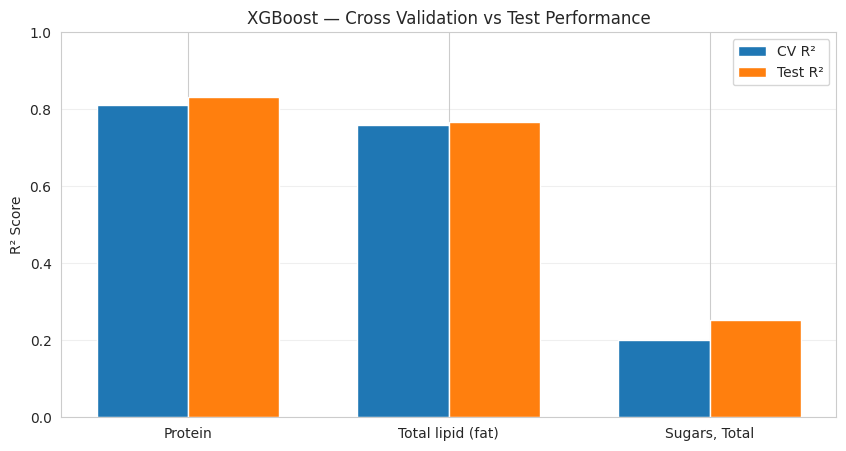

In [ ]:

targets = ["Protein", "Total lipid (fat)", "Sugars, Total"]

cv_scores = [0.8100, 0.7589, 0.2000]
test_scores = [0.8308, 0.7674, 0.2518]

x = np.arange(len(targets))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, cv_scores, width, label="CV R²")
plt.bar(x + width/2, test_scores, width, label="Test R²")

plt.xticks(x, targets)
plt.ylabel("R² Score")
plt.title("XGBoost — Cross Validation vs Test Performance")
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

**Conclusion For cleaned corrupted data:**

The results show that XGBoost outperforms Gradient Boosting and Random Forest across all targets in terms of R², MAE, and RMSE. For Sugars, all models shows low R² values, indicating that this target is significantly more difficult to predict which is most likely cause by the handling of missing values using median imputation, it may have reduced the variability and changed the distribution of the features, which affected model performance




### 2.4 Randomized search for xgboost

In [ ]:
"""from sklearn.model_selection import RandomizedSearchCV
import joblib

param_distributions = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__learning_rate': [0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 4, 5],
    'estimator__subsample': [0.8, 0.9, 1.0],
    'estimator__colsample_bytree': [0.8, 0.9, 1.0],
}

random_search_xgb_corr = RandomizedSearchCV(
    estimator=MultiOutputRegressor(
        XGBRegressor(
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
    ),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_xgb_corr.fit(X_corr_train, y_corr_train)

print("Best parameters:")
print(random_search_xgb_corr.best_params_)
print(f"Best CV R²: {random_search_xgb_corr.best_score_:.4f}")

joblib.dump(random_search_xgb_corr, "random_search_xgb_corr.pkl")
print("Saved to random_search_xgb_corr.pkl")"""

'from sklearn.model_selection import RandomizedSearchCV\nimport joblib\n\nparam_distributions = {\n    \'estimator__n_estimators\': [100, 200, 300],\n    \'estimator__learning_rate\': [0.05, 0.1, 0.2],\n    \'estimator__max_depth\': [3, 4, 5],\n    \'estimator__subsample\': [0.8, 0.9, 1.0],\n    \'estimator__colsample_bytree\': [0.8, 0.9, 1.0],\n}\n\nrandom_search_xgb_corr = RandomizedSearchCV(\n    estimator=MultiOutputRegressor(\n        XGBRegressor(\n            random_state=42,\n            n_jobs=-1,\n            verbosity=0\n        )\n    ),\n    param_distributions=param_distributions,\n    n_iter=20,\n    cv=3,\n    scoring=\'r2\',\n    n_jobs=-1,\n    verbose=1,\n    random_state=42\n)\n\nrandom_search_xgb_corr.fit(X_corr_train, y_corr_train)\n\nprint("Best parameters:")\nprint(random_search_xgb_corr.best_params_)\nprint(f"Best CV R²: {random_search_xgb_corr.best_score_:.4f}")\n\njoblib.dump(random_search_xgb_corr, "random_search_xgb_corr.pkl")\nprint("Saved to random_search

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'estimator__subsample': 0.8, 'estimator__n_estimators': 300, 'estimator__max_depth': 4, 'estimator__learning_rate': 0.05, 'estimator__colsample_bytree': 0.8}
Best CV R²: 0.5855
Saved to random_search_xgb_corr.pkl

### 2.5 Training on tuned model

In [ ]:

xgb = MultiOutputRegressor(XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample= 0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
))
xgb.fit(X_corr_train, y_corr_train)
y_pred_xgb_train_corr = xgb.predict(X_corr_train)
y_pred_xgb_test_corr  = xgb.predict(X_corr_test)
evaluate(y_corr_train, y_pred_xgb_train_corr, "XGBoost - Train")
evaluate(y_corr_test,  y_pred_xgb_test_corr,  "XGBoost - Test")

XGBoost - Train

Protein
R²  : 0.912
MAE : 1.951
RMSE: 2.999

Total lipid (fat)
R²  : 0.899
MAE : 2.196
RMSE: 3.414

Sugars, Total
R²  : 0.643
MAE : 1.792
RMSE: 4.108
XGBoost - Test

Protein
R²  : 0.846
MAE : 2.491
RMSE: 3.951

Total lipid (fat)
R²  : 0.765
MAE : 3.050
RMSE: 5.317

Sugars, Total
R²  : 0.236
MAE : 2.396
RMSE: 5.614


Hyperparameter tuning led to a slight improvement in the prediction performance for Protein, . For Total Lipid (Fat), the performance remained  unchanged, as for  the performance for Sugars it got worst on the test set but improved training performance, which indicates increasing in overfitting.

the untuned XGBoost model provides a more balanced and stable performance across all targets for this corrupted dataset